# IMC Round 4 Manual Challenge: Aether Crystal Options Pricing

## Problem description

This notebook analyzes the Round 4 manual challenge **"Vanilla Just Isn't Exotic Enough"**.

You are given one underlying product, `AETHER_CRYSTAL`, and several options written on it:

- the underlying `AC`,
- 2-week and 3-week vanilla calls and puts,
- a 3-week chooser option,
- a 3-week binary put,
- a 3-week knock-out put.

The challenge is standalone. You choose your buy/sell orders at the start of the round and hold all positions to expiry. There is no dynamic trading and no connection to Round 1 trading data.

The underlying follows a discrete-time Geometric Brownian Motion with:

- initial spot approximately 50,
- zero risk-neutral drift,
- annualized volatility 251%,
- 252 trading days per year,
- 4 simulation steps per trading day.

The goal is to estimate the fair value of each contract, compare that fair value with the displayed bid/ask, and construct a portfolio with positive expected PnL while controlling risk.

For a buy order:

$$
\text{PnL} = \text{payoff} - \text{ask}.
$$

For a sell order:

$$
\text{PnL} = \text{bid} - \text{payoff}.
$$

The challenge multiplies per-contract PnL by a contract size of 3000.

## Step 1. Import packages

Run this cell first. The notebook only uses standard scientific Python packages: `numpy`, `pandas`, and `matplotlib`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

## Step 2. Set model assumptions

The bid/ask of the underlying is 49.975 / 50.025, so the midpoint is 50. This is why the simulation uses `S0 = 50.0`.

The challenge states that 1 trading year has `252 * 4 = 1008` simulation steps.

- 2 weeks = 10 trading days = 40 steps.
- 3 weeks = 15 trading days = 60 steps.

In [2]:
S0 = 50.0
SIGMA = 2.51

TRADING_DAYS_PER_YEAR = 252
STEPS_PER_DAY = 4
STEPS_PER_YEAR = TRADING_DAYS_PER_YEAR * STEPS_PER_DAY

CONTRACT_SIZE = 3000

STEPS_2W = int(round(2 * 5 * STEPS_PER_DAY))
STEPS_3W = int(round(3 * 5 * STEPS_PER_DAY))
DT = 1 / STEPS_PER_YEAR

N_PATHS = 500_000
RANDOM_SEED = 42

print("STEPS_PER_YEAR:", STEPS_PER_YEAR)
print("STEPS_2W:", STEPS_2W)
print("STEPS_3W:", STEPS_3W)
print("DT:", DT)

STEPS_PER_YEAR: 1008
STEPS_2W: 40
STEPS_3W: 60
DT: 0.000992063492063492


## Step 3. Enter the market table

This cell records the products, bid/ask prices, maximum sizes, strikes, expiries, and exotic-option parameters.

Sign convention later in the notebook:

- positive quantity means buy,
- negative quantity means sell.

In [3]:
contracts = {
    "AC": {
        "type": "underlying",
        "bid": 49.975,
        "ask": 50.025,
        "max_buy": 200,
        "max_sell": 200,
    },
    "AC_50_P": {
        "type": "put",
        "K": 50,
        "expiry_steps": STEPS_3W,
        "bid": 12.00,
        "ask": 12.05,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_50_C": {
        "type": "call",
        "K": 50,
        "expiry_steps": STEPS_3W,
        "bid": 12.00,
        "ask": 12.05,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_35_P": {
        "type": "put",
        "K": 35,
        "expiry_steps": STEPS_3W,
        "bid": 4.33,
        "ask": 4.35,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_40_P": {
        "type": "put",
        "K": 40,
        "expiry_steps": STEPS_3W,
        "bid": 6.50,
        "ask": 6.55,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_45_P": {
        "type": "put",
        "K": 45,
        "expiry_steps": STEPS_3W,
        "bid": 9.05,
        "ask": 9.10,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_60_C": {
        "type": "call",
        "K": 60,
        "expiry_steps": STEPS_3W,
        "bid": 8.80,
        "ask": 8.85,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_50_P_2": {
        "type": "put",
        "K": 50,
        "expiry_steps": STEPS_2W,
        "bid": 9.70,
        "ask": 9.75,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_50_C_2": {
        "type": "call",
        "K": 50,
        "expiry_steps": STEPS_2W,
        "bid": 9.70,
        "ask": 9.75,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_50_CO": {
        "type": "chooser",
        "K": 50,
        "choose_steps": STEPS_2W,
        "expiry_steps": STEPS_3W,
        "bid": 22.20,
        "ask": 22.30,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_40_BP": {
        "type": "binary_put",
        "K": 40,
        "payout": 10,
        "expiry_steps": STEPS_3W,
        "bid": 5.00,
        "ask": 5.10,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_45_KO": {
        "type": "ko_put",
        "K": 45,
        "barrier": 35,
        "expiry_steps": STEPS_3W,
        "bid": 0.15,
        "ask": 0.175,
        "max_buy": 500,
        "max_sell": 500,
    },
}

market_table = pd.DataFrame.from_dict(contracts, orient="index")
market_table

,type,bid,ask,max_buy,max_sell,K,expiry_steps,choose_steps,payout,barrier
AC,underlying,49.975,50.025,200,200,NaN,NaN,NaN,NaN,NaN
AC_50_P,put,12.000,12.050,50,50,50.0,60.0,NaN,NaN,NaN
AC_50_C,call,12.000,12.050,50,50,50.0,60.0,NaN,NaN,NaN
AC_35_P,put,4.330,4.350,50,50,35.0,60.0,NaN,NaN,NaN
AC_40_P,put,6.500,6.550,50,50,40.0,60.0,NaN,NaN,NaN
AC_45_P,put,9.050,9.100,50,50,45.0,60.0,NaN,NaN,NaN
AC_60_C,call,8.800,8.850,50,50,60.0,60.0,NaN,NaN,NaN
AC_50_P_2,put,9.700,9.750,50,50,50.0,40.0,NaN,NaN,NaN
AC_50_C_2,call,9.700,9.750,50,50,50.0,40.0,NaN,NaN,NaN
AC_50_CO,chooser,22.200,22.300,50,50,50.0,60.0,40.0,NaN,NaN


## Step 4. Simulate the underlying paths

The exact discrete GBM update is:

$$
S_{t+\Delta t} = S_t \exp \left((\mu -\frac{\sigma^2}{2})\Delta t + \sigma\sqrt{\Delta t} \; \mathrm{Z}\right),
$$

where $\mathrm{Z}\sim N(0,1)$.

The drift is zero in the GBM equation (i.e. $\mu = 0$), but the log update contains the usual $-\frac12\sigma^2\Delta t$ adjustment.

In [4]:
def simulate_gbm_paths(S0, sigma, n_paths, n_steps, dt, seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_paths, n_steps))
    log_returns = (-0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(log_returns, axis=1)
    paths = S0 * np.exp(log_paths)
    paths = np.concatenate([np.full((n_paths, 1), S0), paths], axis=1)
    return paths

paths = simulate_gbm_paths(
    S0=S0,
    sigma=SIGMA,
    n_paths=N_PATHS,
    n_steps=STEPS_3W,
    dt=DT,
    seed=RANDOM_SEED,
)

S_2W = paths[:, STEPS_2W]
S_3W = paths[:, STEPS_3W]

print("paths shape:", paths.shape)
print("Mean S_2W:", S_2W.mean())
print("Mean S_3W:", S_3W.mean())
print("Median S_3W:", np.median(S_3W))

paths shape: (500000, 61)
Mean S_2W: 49.997443931657685
Mean S_3W: 49.97996961628291
Median S_3W: 41.48102511960558


## Step 5. Visualize the simulated terminal distribution

This helps you understand why option prices are large. The volatility is extremely high, so the right tail can be very large even over only 3 weeks.

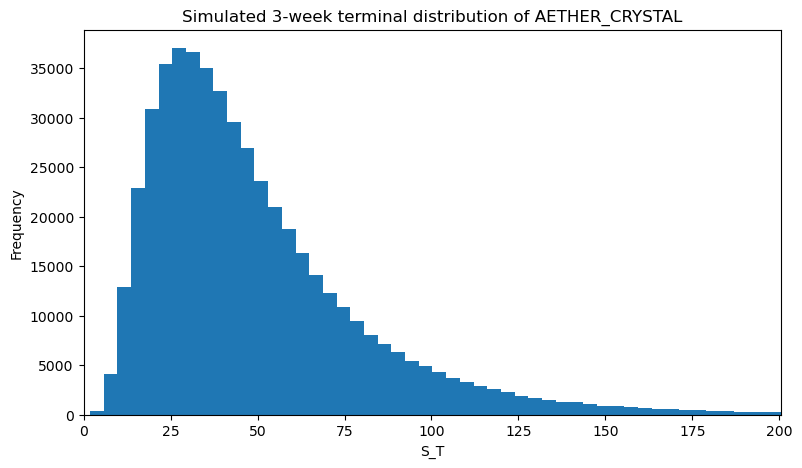

count    500000.000000
mean         49.979970
std          33.690336
min           1.857543
1%            9.993051
5%           15.136069
10%          18.949434
50%          41.481025
90%          90.807993
95%         113.372067
99%         172.005227
max         789.154372
dtype: float64

In [5]:
plt.figure(figsize=(9, 5))
plt.hist(S_3W, bins=200)
plt.title("Simulated 3-week terminal distribution of AETHER_CRYSTAL")
plt.xlabel("S_T")
plt.ylabel("Frequency")
plt.xlim(0, np.percentile(S_3W, 99.5))
plt.show()

summary = pd.Series(S_3W).describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])
summary

## Step 6. Define payoff functions

This cell implements the payoff rule for each product.

Important interpretations used here:

1. The chooser option chooses call if `S_choose >= K`, otherwise put.
2. The binary put pays 10 if `S_T < 40`, otherwise 0.
3. The knock-out put has strike 45 and barrier 35. If the path ever goes below 35 at a discrete simulation point, it becomes worthless.

In [6]:
def payoff_for_contract(name, contract, paths):
    ctype = contract["type"]

    if ctype == "underlying":
        return paths[:, STEPS_3W]

    if ctype == "call":
        K = contract["K"]
        T = contract["expiry_steps"]
        ST = paths[:, T]
        return np.maximum(ST - K, 0)

    if ctype == "put":
        K = contract["K"]
        T = contract["expiry_steps"]
        ST = paths[:, T]
        return np.maximum(K - ST, 0)

    if ctype == "binary_put":
        K = contract["K"]
        payout = contract["payout"]
        T = contract["expiry_steps"]
        ST = paths[:, T]
        return payout * (ST < K)

    if ctype == "ko_put":
        K = contract["K"]
        barrier = contract["barrier"]
        T = contract["expiry_steps"]
        ST = paths[:, T]
        path_until_T = paths[:, :T + 1]
        knocked_out = np.any(path_until_T < barrier, axis=1)
        vanilla_put_payoff = np.maximum(K - ST, 0)
        return np.where(knocked_out, 0, vanilla_put_payoff)

    if ctype == "chooser":
        K = contract["K"]
        choose_t = contract["choose_steps"]
        T = contract["expiry_steps"]
        S_choose = paths[:, choose_t]
        ST = paths[:, T]
        call_payoff = np.maximum(ST - K, 0)
        put_payoff = np.maximum(K - ST, 0)
        return np.where(S_choose >= K, call_payoff, put_payoff)

    raise ValueError(f"Unknown contract type: {ctype}")

payoffs = {name: payoff_for_contract(name, contract, paths) for name, contract in contracts.items()}
payoff_df = pd.DataFrame(payoffs)
payoff_df.head()

,AC,AC_50_P,AC_50_C,AC_35_P,AC_40_P,AC_45_P,AC_60_C,AC_50_P_2,AC_50_C_2,AC_50_CO,AC_40_BP,AC_45_KO
0,56.497627,0.000000,6.497627,0.000000,0.000000,0.000000,0.0,0.199424,0.000000,0.000000,0,0.000000
1,17.146846,32.853154,0.000000,17.853154,22.853154,27.853154,0.0,28.243271,0.000000,32.853154,10,0.000000
2,32.778038,17.221962,0.000000,2.221962,7.221962,12.221962,0.0,13.938588,0.000000,17.221962,10,0.000000
3,38.105905,11.894095,0.000000,0.000000,1.894095,6.894095,0.0,0.000000,1.970482,0.000000,10,6.894095
4,38.174960,11.825040,0.000000,0.000000,1.825040,6.825040,0.0,0.000000,7.106127,0.000000,10,0.000000


## Step 7. Compute fair values and bid/ask edges

For each contract:

- buy edge = fair value - ask,
- sell edge = bid - fair value.

A positive buy edge means the contract looks cheap. A positive sell edge means the contract looks expensive.

In [7]:
rows = []

for name, contract in contracts.items():
    fair = payoff_df[name].mean()
    bid = contract["bid"]
    ask = contract["ask"]
    buy_edge = fair - ask
    sell_edge = bid - fair

    rows.append({
        "contract": name,
        "type": contract["type"],
        "fair_value": fair,
        "bid": bid,
        "ask": ask,
        "buy_edge": buy_edge,
        "sell_edge": sell_edge,
        "best_side": "BUY" if buy_edge > sell_edge else "SELL",
        "best_edge": max(buy_edge, sell_edge),
        "max_buy": contract["max_buy"],
        "max_sell": contract["max_sell"],
    })

edge_table = pd.DataFrame(rows).sort_values("best_edge", ascending=False).reset_index(drop=True)
edge_table

,contract,type,fair_value,bid,ask,buy_edge,sell_edge,best_side,best_edge,max_buy,max_sell
0,AC_50_CO,chooser,21.864573,22.200,22.300,-0.435427,0.335427,SELL,0.335427,50,50
1,AC_40_BP,binary_put,4.764500,5.000,5.100,-0.335500,0.235500,SELL,0.235500,50,50
2,AC_50_P_2,put,9.865477,9.700,9.750,0.115477,-0.165477,BUY,0.115477,50,50
3,AC_50_C_2,call,9.862921,9.700,9.750,0.112921,-0.162921,BUY,0.112921,50,50
4,AC_60_C,call,8.760441,8.800,8.850,-0.089559,0.039559,SELL,0.039559,50,50
5,AC_45_KO,ko_put,0.205626,0.150,0.175,0.030626,-0.055626,BUY,0.030626,500,500
6,AC_50_C,call,11.994400,12.000,12.050,-0.055600,0.005600,SELL,0.005600,50,50
7,AC_35_P,put,4.330159,4.330,4.350,-0.019841,-0.000159,SELL,-0.000159,50,50
8,AC_40_P,put,6.500217,6.500,6.550,-0.049783,-0.000217,SELL,-0.000217,50,50
9,AC,underlying,49.979970,49.975,50.025,-0.045030,-0.004970,SELL,-0.004970,200,200


## Step 8. Compute single-contract risk statistics

This step checks the distribution of PnL for buying or selling one unit of each contract.

This is important because selling options may look good in expectation but can have large left-tail losses.

In [8]:
risk_rows = []

for name, contract in contracts.items():
    payoff = payoff_df[name].values
    bid = contract["bid"]
    ask = contract["ask"]

    buy_pnl = payoff - ask
    sell_pnl = bid - payoff

    risk_rows.append({
        "contract": name,
        "buy_mean": buy_pnl.mean(),
        "buy_std": buy_pnl.std(),
        "buy_p5": np.percentile(buy_pnl, 5),
        "buy_p1": np.percentile(buy_pnl, 1),
        "sell_mean": sell_pnl.mean(),
        "sell_std": sell_pnl.std(),
        "sell_p5": np.percentile(sell_pnl, 5),
        "sell_p1": np.percentile(sell_pnl, 1),
    })

risk_table = pd.DataFrame(risk_rows)
risk_table

,contract,buy_mean,buy_std,buy_p5,buy_p1,sell_mean,sell_std,sell_p5,sell_p1
0,AC,-0.045030,33.690302,-34.888931,-40.031949,-0.004970,33.690302,-63.397067,-122.030227
1,AC_50_P,-0.035570,12.609021,-12.050000,-12.050000,-0.014430,12.609021,-22.863931,-28.006949
2,AC_50_C,-0.055600,26.226652,-12.050000,-12.050000,0.005600,26.226652,-51.372067,-110.005227
3,AC_35_P,-0.019841,6.931460,-4.350000,-4.350000,-0.000159,6.931460,-15.533931,-20.676949
4,AC_40_P,-0.049783,8.850796,-6.550000,-6.550000,-0.000217,8.850796,-18.363931,-23.506949
5,AC_45_P,-0.022774,10.759255,-9.100000,-9.100000,-0.027226,10.759255,-20.813931,-25.956949
6,AC_60_C,-0.089559,23.434963,-8.850000,-8.850000,0.039559,23.434963,-44.572067,-103.205227
7,AC_50_P_2,0.115477,10.968541,-9.750000,-9.750000,-0.165477,10.968541,-20.932151,-26.490229
8,AC_50_C_2,0.112921,19.853086,-9.750000,-9.750000,-0.162921,19.853086,-40.830503,-81.002295
9,AC_50_CO,-0.435427,24.773987,-22.300000,-22.300000,0.335427,24.773987,-40.837062,-99.728318


## Step 9. Estimate delta for each contract

Delta measures approximate exposure to the underlying.

This notebook estimates delta by bumping `S0` slightly up and down and reusing the same random numbers for both simulations.

The underlying has delta 1 by definition.

In [9]:
def estimate_delta(contract_name, contract, n_paths=200_000, bump=0.10, seed=123):
    if contract["type"] == "underlying":
        return 1.0

    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_paths, STEPS_3W))
    log_returns = (-0.5 * SIGMA**2) * DT + SIGMA * np.sqrt(DT) * Z
    log_paths = np.cumsum(log_returns, axis=1)

    def make_paths(start_price):
        p = start_price * np.exp(log_paths)
        p = np.concatenate([np.full((n_paths, 1), start_price), p], axis=1)
        return p

    paths_up = make_paths(S0 + bump)
    paths_down = make_paths(S0 - bump)

    payoff_up = payoff_for_contract(contract_name, contract, paths_up).mean()
    payoff_down = payoff_for_contract(contract_name, contract, paths_down).mean()

    return (payoff_up - payoff_down) / (2 * bump)


deltas = {name: estimate_delta(name, contract) for name, contract in contracts.items()}
delta_table = pd.DataFrame({"contract": list(deltas.keys()), "delta": list(deltas.values())})
delta_table

,contract,delta
0,AC,1.000000
1,AC_50_P,-0.379167
2,AC_50_C,0.619433
3,AC_35_P,-0.186528
4,AC_40_P,-0.250830
5,AC_45_P,-0.315073
6,AC_60_C,0.499530
7,AC_50_P_2,-0.402081
8,AC_50_C_2,0.597181
9,AC_50_CO,0.206949


## Step 10. Define portfolio PnL and portfolio statistics

This cell lets you evaluate any portfolio.

Again, positive quantity means buy, and negative quantity means sell.

In [10]:
def portfolio_pnl(positions):
    total = np.zeros(len(payoff_df))

    for name, qty in positions.items():
        if qty == 0:
            continue

        contract = contracts[name]
        payoff = payoff_df[name].values

        if qty > 0:
            total += qty * (payoff - contract["ask"])
        else:
            total += (-qty) * (contract["bid"] - payoff)

    return CONTRACT_SIZE * total


def portfolio_delta(positions):
    return CONTRACT_SIZE * sum(qty * deltas[name] for name, qty in positions.items())


def portfolio_stats(positions):
    pnl = portfolio_pnl(positions)
    return {
        "mean": pnl.mean(),
        "std": pnl.std(),
        "p10": np.percentile(pnl, 10),
        "p5": np.percentile(pnl, 5),
        "p1": np.percentile(pnl, 1),
        "min": pnl.min(),
        "delta": portfolio_delta(positions),
        "sharpe_like": pnl.mean() / pnl.std() if pnl.std() > 0 else np.nan,
    }


def display_portfolio(name, positions):
    clean_positions = {k: v for k, v in positions.items() if v != 0}
    stats = portfolio_stats(clean_positions)
    print("=" * 80)
    print(name)
    print("=" * 80)
    print("Positions:")
    for contract, qty in clean_positions.items():
        side = "BUY" if qty > 0 else "SELL"
        print(f"  {contract}: {side} {abs(qty)}")
    print("Stats:")
    for k, v in stats.items():
        print(f"  {k}: {v:,.2f}")
    return stats

## Step 11. Build a naive max-edge portfolio

This portfolio takes the maximum allowed position in the best edge direction for every product whose best edge is positive.

This is useful as a benchmark, but it may be too risky.

In [11]:
naive_positions = {}

for _, row in edge_table.iterrows():
    name = row["contract"]
    if row["best_edge"] <= 0:
        naive_positions[name] = 0
    elif row["best_side"] == "BUY":
        naive_positions[name] = contracts[name]["max_buy"]
    else:
        naive_positions[name] = -contracts[name]["max_sell"]

display_portfolio("Naive max-edge portfolio", naive_positions)

Naive max-edge portfolio
Positions:
  AC_50_CO: SELL 50
  AC_40_BP: SELL 50
  AC_50_P_2: BUY 50
  AC_50_C_2: BUY 50
  AC_60_C: SELL 50
  AC_45_KO: BUY 500
  AC_50_C: SELL 50
Stats:
  mean: 172,611.57
  std: 9,391,048.31
  p10: -8,204,827.05
  p5: -16,972,127.25
  p1: -39,882,051.30
  min: -275,821,659.10
  delta: -136,000.73
  sharpe_like: 0.02


{'mean': np.float64(172611.56778377967),
 'std': np.float64(9391048.312497322),
 'p10': np.float64(-8204827.050347032),
 'p5': np.float64(-16972127.251315374),
 'p1': np.float64(-39882051.30429205),
 'min': np.float64(-275821659.1010102),
 'delta': np.float64(-136000.73122796082),
 'sharpe_like': np.float64(0.01838043656468825)}

## Step 12. Delta hedge the portfolio using the underlying

This cell automatically chooses an `AC` quantity to reduce the portfolio's delta.

Because the maximum `AC` volume is only 200, the hedge may not fully remove delta.

In [12]:
def delta_hedge_with_underlying(positions):
    new_positions = dict(positions)

    option_delta_units = 0.0
    for name, qty in new_positions.items():
        if name == "AC":
            continue
        option_delta_units += qty * deltas[name]

    hedge_qty = int(round(-option_delta_units))
    hedge_qty = max(-contracts["AC"]["max_sell"], hedge_qty)
    hedge_qty = min(contracts["AC"]["max_buy"], hedge_qty)

    new_positions["AC"] = hedge_qty
    return new_positions

hedged_naive_positions = delta_hedge_with_underlying(naive_positions)
display_portfolio("Delta-hedged naive portfolio", hedged_naive_positions)

Delta-hedged naive portfolio
Positions:
  AC_50_CO: SELL 50
  AC_40_BP: SELL 50
  AC_50_P_2: BUY 50
  AC_50_C_2: BUY 50
  AC_60_C: SELL 50
  AC_45_KO: BUY 500
  AC_50_C: SELL 50
  AC: BUY 45
Stats:
  mean: 166,532.47
  std: 6,326,619.45
  p10: -4,565,074.90
  p5: -8,650,108.90
  p1: -23,719,174.07
  min: -176,039,193.92
  delta: -1,000.73
  sharpe_like: 0.03


{'mean': np.float64(166532.46598197272),
 'std': np.float64(6326619.447463118),
 'p10': np.float64(-4565074.902380136),
 'p5': np.float64(-8650108.904674122),
 'p1': np.float64(-23719174.073654253),
 'min': np.float64(-176039193.91506672),
 'delta': np.float64(-1000.7312279608129),
 'sharpe_like': np.float64(0.02632250404262103)}

## Step 13. Test important relative-value portfolios

These portfolios compare related products directly.

Examples:

- chooser versus call + put,
- binary put versus vanilla put,
- knock-out put versus vanilla put.

These are useful because they reduce pure directional guessing and focus on relative mispricing.

In [13]:
relative_value_portfolios = {
    "Long chooser, short 3-week 50 call and put": {
        "AC_50_CO": 50,
        "AC_50_C": -50,
        "AC_50_P": -50,
    },
    "Short chooser, long 3-week 50 call and put": {
        "AC_50_CO": -50,
        "AC_50_C": 50,
        "AC_50_P": 50,
    },
    "Long binary put, short 40 put": {
        "AC_40_BP": 50,
        "AC_40_P": -50,
    },
    "Short binary put, long 40 put": {
        "AC_40_BP": -50,
        "AC_40_P": 50,
    },
    "Long KO put, short 45 vanilla put": {
        "AC_45_KO": 500,
        "AC_45_P": -50,
    },
    "Short KO put, long 45 vanilla put": {
        "AC_45_KO": -500,
        "AC_45_P": 50,
    },
}

relative_results = []

for name, positions in relative_value_portfolios.items():
    hedged_positions = delta_hedge_with_underlying(positions)
    stats = display_portfolio(name + " with AC delta hedge", hedged_positions)
    relative_results.append({"name": name, **stats, "positions": hedged_positions})

relative_results_df = pd.DataFrame(relative_results).sort_values("mean", ascending=False)
relative_results_df[["name", "mean", "std", "p5", "p1", "delta", "sharpe_like"]]

Long chooser, short 3-week 50 call and put with AC delta hedge
Positions:
  AC_50_CO: BUY 50
  AC_50_C: SELL 50
  AC_50_P: SELL 50
  AC: BUY 2
Stats:
  mean: -66,908.81
  std: 944,079.84
  p10: -1,012,449.16
  p5: -2,081,144.65
  p1: -3,992,132.33
  min: -20,039,360.02
  delta: 1,002.54
  sharpe_like: -0.07
Short chooser, long 3-week 50 call and put with AC delta hedge
Positions:
  AC_50_CO: SELL 50
  AC_50_C: BUY 50
  AC_50_P: BUY 50
  AC: SELL 2
Stats:
  mean: 36,608.81
  std: 944,079.84
  p10: -523,073.37
  p5: -663,372.37
  p1: -1,016,719.91
  min: -4,720,076.23
  delta: -1,002.54
  sharpe_like: 0.04
Long binary put, short 40 put with AC delta hedge
Positions:
  AC_40_BP: BUY 50
  AC_40_P: SELL 50
  AC: SELL 7
Stats:
  mean: -50,461.91
  std: 913,022.88
  p10: -1,214,924.70
  p5: -1,630,369.70
  p1: -2,446,428.40
  min: -15,312,766.81
  delta: -1,187.99
  sharpe_like: -0.06
Short binary put, long 40 put with AC delta hedge
Positions:
  AC_40_BP: SELL 50
  AC_40_P: BUY 50
  AC: BUY 

,name,mean,std,p5,p1,delta,sharpe_like
4,"Long KO put, short 45 vanilla put",41542.011116,2.423830e+06,-2.899015e+06,-6.592904e+06,69.547068,0.017139
1,"Short chooser, long 3-week 50 call and put",36608.807085,9.440798e+05,-6.633724e+05,-1.016720e+06,-1002.539842,0.038777
3,"Short binary put, long 40 put",26911.913117,9.130229e+05,-1.561733e+06,-1.866027e+06,1187.991432,0.029476
2,"Long binary put, short 40 put",-50461.913117,9.130229e+05,-1.630370e+06,-2.446428e+06,-1187.991432,-0.055269
0,"Long chooser, short 3-week 50 call and put",-66908.807085,9.440798e+05,-2.081145e+06,-3.992132e+06,1002.539842,-0.070872
5,"Short KO put, long 45 vanilla put",-89692.011116,2.423830e+06,-1.453060e+06,-1.107117e+07,-69.547068,-0.037004


## Step 14. Run a randomized portfolio search

A full brute-force search over all contracts is too large. Instead, this cell samples many random portfolios, delta-hedges them with `AC`, and keeps portfolios satisfying risk constraints.

You can make this more conservative by increasing the required `MIN_P5` and `MIN_P1`, or by lowering `N_RANDOM_PORTFOLIOS`.

In [14]:
N_RANDOM_PORTFOLIOS = 50_000
SEARCH_SEED = 2026

MIN_P5 = -1_500_000
MIN_P1 = -3_000_000
MAX_ABS_DELTA = 300_000
TAIL_PENALTY = 0.25

search_contracts = [name for name in contracts.keys() if name != "AC"]
rng = np.random.default_rng(SEARCH_SEED)

# Candidate quantities. You can adjust these grids.
qty_choices = {}
for name in search_contracts:
    if name == "AC_45_KO":
        qty_choices[name] = np.array([-500, -250, 0, 250, 500])
    else:
        qty_choices[name] = np.array([-50, -25, 0, 25, 50])

results = []

for _ in range(N_RANDOM_PORTFOLIOS):
    positions = {name: int(rng.choice(qty_choices[name])) for name in search_contracts}
    positions = delta_hedge_with_underlying(positions)
    stats = portfolio_stats(positions)

    if stats["p5"] < MIN_P5:
        continue
    if stats["p1"] < MIN_P1:
        continue
    if abs(stats["delta"]) > MAX_ABS_DELTA:
        continue

    objective = stats["mean"] + TAIL_PENALTY * stats["p5"]
    results.append({
        "objective": objective,
        **stats,
        "positions": positions,
    })

results_df = pd.DataFrame(results)

if len(results_df) == 0:
    print("No portfolios passed the current constraints. Try relaxing the risk filters.")
else:
    results_df = results_df.sort_values("objective", ascending=False).reset_index(drop=True)
    display(results_df[["objective", "mean", "std", "p10", "p5", "p1", "min", "delta", "sharpe_like"]].head(10))

,objective,mean,std,p10,p5,p1,min,delta,sharpe_like
0,-66451.544006,18392.205994,6.518847e+05,-339375.000000,-339375.000000,-3.393750e+05,-3.393750e+05,-262.351134,0.028214
1,-77614.840726,24502.791353,3.633747e+05,-234008.870314,-408470.528315,-5.817242e+05,-2.121538e+06,986.071324,0.067431
2,-106455.456886,41999.550305,6.701497e+05,-516449.977066,-593820.028766,-7.273600e+05,-2.579038e+06,-689.692112,0.062672
3,-120221.655425,17627.255990,6.265951e+05,-519694.669836,-551395.645660,-5.725336e+05,-5.774245e+05,1027.730071,0.028132
4,-131088.079232,14471.647989,5.215524e+05,-483029.093821,-582238.908881,-6.524169e+05,-6.692979e+05,672.301403,0.027747
5,-152446.067601,9248.161957,1.026517e+06,-628923.265818,-646776.918233,-9.496613e+05,-1.036740e+06,42.949871,0.009009
6,-153943.808184,85087.243037,1.319612e+06,-910423.008636,-956124.204884,-1.317402e+06,-1.461936e+06,-836.497322,0.064479
7,-155229.779240,1801.470760,6.140634e+05,-628125.000000,-628125.000000,-6.281250e+05,-6.281250e+05,-929.294640,0.002934
8,-156846.906680,59083.586562,1.060821e+06,-807827.138253,-863721.972965,-1.000387e+06,-1.066632e+06,-308.549918,0.055696
9,-157688.388176,-14372.959156,5.268321e+05,-522037.447380,-573261.716081,-6.125710e+05,-6.220490e+05,-1017.896803,-0.027282


## Step 15. Print the best randomized-search portfolio

This gives a directly readable list of orders to enter.

Remember: this is based on the model assumptions and simulation. Before submitting, compare it with your own risk tolerance.

In [15]:
if "results_df" in globals() and len(results_df) > 0:
    best = results_df.iloc[0]
    best_positions = {k: v for k, v in best["positions"].items() if v != 0}

    print("Best portfolio under current objective and risk constraints:")
    print()
    for contract, qty in best_positions.items():
        side = "BUY" if qty > 0 else "SELL"
        print(f"{contract}: {side} {abs(qty)}")

    print("Statistics:")
    for key in ["objective", "mean", "std", "p10", "p5", "p1", "min", "delta", "sharpe_like"]:
        print(f"{key}: {best[key]:,.2f}")

    display_portfolio("Best randomized-search portfolio", best_positions)
else:
    print("No valid search results available. Run Step 14 first, or relax the constraints.")

Best portfolio under current objective and risk constraints:

AC_50_C: SELL 25
AC_35_P: BUY 25
AC_40_P: SELL 25
AC_45_P: SELL 25
AC_60_C: BUY 50
AC_40_BP: SELL 50
AC: SELL 25
Statistics:
objective: -66,451.54
mean: 18,392.21
std: 651,884.68
p10: -339,375.00
p5: -339,375.00
p1: -339,375.00
min: -339,375.00
delta: -262.35
sharpe_like: 0.03
Best randomized-search portfolio
Positions:
  AC_50_C: SELL 25
  AC_35_P: BUY 25
  AC_40_P: SELL 25
  AC_45_P: SELL 25
  AC_60_C: BUY 50
  AC_40_BP: SELL 50
  AC: SELL 25
Stats:
  mean: 18,392.21
  std: 651,884.68
  p10: -339,375.00
  p5: -339,375.00
  p1: -339,375.00
  min: -339,375.00
  delta: -262.35
  sharpe_like: 0.03


## Step 16. Plot the PnL distribution of any chosen portfolio

Set `chosen_positions` to the portfolio you want to inspect. By default, this cell uses the best randomized-search portfolio if available.

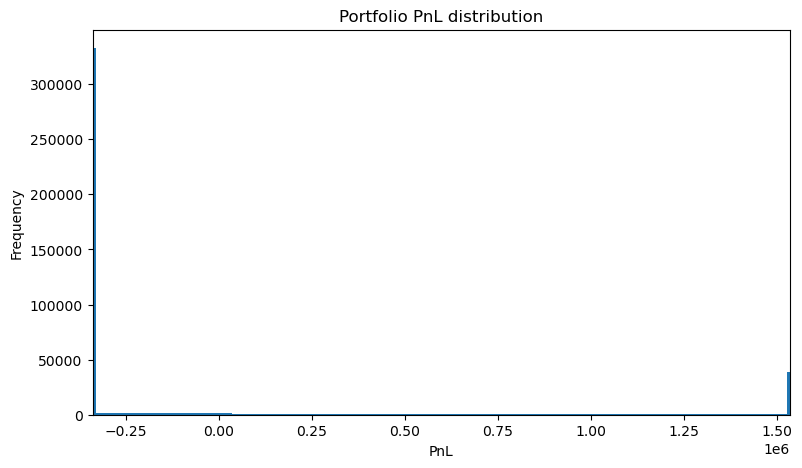

count    5.000000e+05
mean     1.839221e+04
std      6.518853e+05
min     -3.393750e+05
1%      -3.393750e+05
5%      -3.393750e+05
10%     -3.393750e+05
50%     -3.393750e+05
90%      1.410830e+06
95%      1.535625e+06
99%      1.535625e+06
max      1.535625e+06
dtype: float64

In [16]:
if "results_df" in globals() and len(results_df) > 0:
    chosen_positions = {k: v for k, v in results_df.iloc[0]["positions"].items() if v != 0}
else:
    chosen_positions = hedged_naive_positions

pnl = portfolio_pnl(chosen_positions)

plt.figure(figsize=(9, 5))
plt.hist(pnl, bins=200)
plt.title("Portfolio PnL distribution")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.xlim(np.percentile(pnl, 0.5), np.percentile(pnl, 99.5))
plt.show()

pd.Series(pnl).describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])

## Step 17. Manual override: evaluate your own proposed order

Edit the dictionary below and run the cell.

Positive quantity means buy. Negative quantity means sell.

For example:

```python
my_positions = {
    "AC_50_CO": 50,
    "AC_50_C": -50,
    "AC_50_P": -50,
    "AC": 10,
}
```

In [17]:
my_positions = {
    # "AC": 0,
    # "AC_50_P": 0,
    # "AC_50_C": 0,
    # "AC_35_P": 0,
    # "AC_40_P": 0,
    # "AC_45_P": 0,
    # "AC_60_C": 0,
    # "AC_50_P_2": 0,
    # "AC_50_C_2": 0,
    # "AC_50_CO": 0,
    # "AC_40_BP": 0,
    # "AC_45_KO": 0,
}

# Optional: automatically delta hedge with AC.
my_positions_hedged = delta_hedge_with_underlying(my_positions)

display_portfolio("My manually entered portfolio, delta-hedged with AC", my_positions_hedged)

My manually entered portfolio, delta-hedged with AC
Positions:
Stats:
  mean: 0.00
  std: 0.00
  p10: 0.00
  p5: 0.00
  p1: 0.00
  min: 0.00
  delta: 0.00
  sharpe_like: nan


{'mean': np.float64(0.0),
 'std': np.float64(0.0),
 'p10': np.float64(0.0),
 'p5': np.float64(0.0),
 'p1': np.float64(0.0),
 'min': np.float64(0.0),
 'delta': 0,
 'sharpe_like': nan}